# Notebook 03 — Modelling and Scenario Portfolio Selection

**Purpose.** Turn the descriptive findings of notebook 02 into a validated model of the recorded 90+ DPD endpoint over the 24-month window built in notebook 01, then evaluate transparent portfolio-selection scenarios inside the observed Freddie Mac acquisition population.

**Input.** `data/processed/loans_2019_labeled.parquet` — the origination-only table with the corrected `default_24m` target.

**Outputs.** Locked logistic baseline and LightGBM challenger; OOF, random hold-out, and chronological sensitivity metrics; calibration diagnostics; scenario-value comparisons. Reusable charts are saved to `figures/` for notebook 04.

**Non-goals.** Inference about rejected applicants, causal approval effects, realised-loss accounting, multi-vintage validation, macroeconomic stress modelling, or an LGD estimated from this dataset.


## 0. Setup

In [1]:
from pathlib import Path
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.metrics import (
    roc_auc_score, average_precision_score, brier_score_loss,
    roc_curve, precision_recall_curve,
)

import lightgbm as lgb

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)
pd.set_option("display.float_format", "{:.4f}".format)
sns.set_theme(style="whitegrid")

cwd = Path.cwd().resolve()
if (cwd / "pyproject.toml").exists():
    PROJECT_ROOT = cwd
elif (cwd.parent / "pyproject.toml").exists():
    PROJECT_ROOT = cwd.parent
else:
    raise RuntimeError(f"Could not resolve project root from {cwd}")

DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
FIGURES_DIR = PROJECT_ROOT / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

LOANS_FILE = DATA_PROCESSED / "loans_2019_labeled.parquet"
assert LOANS_FILE.exists(), f"Missing {LOANS_FILE}; run notebook 01 first"

SEED = 42
# Avoid platform-specific physical-core probing warnings in constrained runtimes.
os.environ.setdefault("LOKY_MAX_CPU_COUNT", "1")
loans = pd.read_parquet(LOANS_FILE)

# Leakage guard: no post-origination diagnostic may enter modelling.
POST_ORIGINATION_COLUMNS = {
    "max_dpd_24m", "observation_months",
    "last_reporting_period_24m", "prepaid_within_24m",
}
leaked = POST_ORIGINATION_COLUMNS.intersection(loans.columns)
assert not leaked, f"Post-origination columns present in modelling table: {leaked}"
assert loans["loan_sequence_number"].is_unique

print(f"Modelling table: {loans.shape[0]:,} rows × {loans.shape[1]} columns")
print(f"Recorded 90+ DPD rate: {loans['default_24m'].mean() * 100:.3f} %")
print(f"Events:                 {int(loans['default_24m'].sum()):,}")
print(f"first_payment_date:     {int(loans['first_payment_date'].min())} – {int(loans['first_payment_date'].max())}")


Modelling table: 49,946 rows × 20 columns
Recorded 90+ DPD rate: 4.589 %
Events:                 2,292
first_payment_date:     201902 – 202003


## 1. Modelling objectives and design decisions

**Target.** `default_24m` from notebook 01: a loan reaches 90+ days past due at least once during calendar months 0–24 of its observation window. Its prevalence in the 2019 vintage is **4.589%**. This is a recorded-delinquency endpoint, not realized credit loss, charge-off, or foreclosure.

**Population and use case.** The file contains loans already originated and acquired by Freddie Mac—not rejected applications. The model is therefore evaluated as a **portfolio-acquisition / review prioritisation score inside this observed, GSE-eligible population**. It does not estimate approval effects for the full applicant population and cannot support causal claims about rejected borrowers.

**Scoring moment.** The score is assumed to run after preliminary underwriting but **before pricing**. Only information plausibly available then is used. `original_interest_rate` is excluded because it reflects a pricing decision and may encode the originator's own risk assessment. Post-origination diagnostics are excluded by construction and re-checked in section 0.

**Validation design.** Model and hyperparameter selection use five-fold out-of-fold (OOF) predictions on the 70% training sample. The 30% test set stays untouched until the model family and configuration are locked. A chronological early/late-2019 split is also evaluated as a sensitivity analysis; it is not a substitute for validation on another vintage.

**Features.** The logistic baseline uses the FICO, LTV, and DTI bands motivated in notebook 02, plus a parsimonious first-time-buyer/high-LTV indicator. The LightGBM challenger keeps the continuous values. Transformations are deterministic or fitted inside pipelines.

**Metrics and uncertainty.** AUC, PR-AUC, KS, and Brier score describe ranking and probability accuracy. Paired bootstrap intervals quantify uncertainty in model differences. Calibration and business thresholds are chosen from training/OOF evidence only, then frozen before test evaluation.

**Label limitation.** COVID-era assistance fields are absent. We therefore cannot determine whether forbearance increased or suppressed the recorded 90+ DPD endpoint. All probabilities refer strictly to the observed label; no unobserved “economic default” correction is claimed.


## 2. Train/test split

A stratified random split is the primary evaluation design. A chronological split by `first_payment_date` is prepared alongside it: within one 2019 vintage, this mainly tests sensitivity to later origination cohorts and different calendar exposure during the outcome window. The main modelling workflow uses only the random split; section 6 refits the locked logistic specification for the chronological check.


### 2.1 Primary split — stratified random

In [2]:
TARGET = "default_24m"
TEST_SIZE = 0.30

y = loans[TARGET].astype(int)
X = loans.drop(columns=[TARGET])

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=TEST_SIZE,
    stratify=y,
    random_state=SEED,
)

split_summary = pd.DataFrame({
    "n_loans":       [len(y_train), len(y_test), len(y)],
    "n_defaults":    [int(y_train.sum()), int(y_test.sum()), int(y.sum())],
    "default_rate":  [y_train.mean(), y_test.mean(), y.mean()],
}, index=["train", "test", "full"])

print(split_summary.assign(
    n_loans=lambda d: d["n_loans"].map("{:,}".format),
    n_defaults=lambda d: d["n_defaults"].map("{:,}".format),
    default_rate=lambda d: (d["default_rate"] * 100).map("{:.3f} %".format),
))

# Sanity: stratification preserves prevalence to within 0.01 pp.
assert abs(y_train.mean() - y_test.mean()) < 1e-4, "Stratification drift"

      n_loans n_defaults default_rate
train  34,962      1,604      4.588 %
test   14,984        688      4.592 %
full   49,946      2,292      4.589 %


### 2.2 Robustness view — temporal split

Loans with `first_payment_date <= 201909` (originated roughly through August 2019) go into a hypothetical training window; the remainder acts as an out-of-time test set. This is not used to fit the main models, but the prevalence contrast is worth noting: the later cohort spends a larger share of its 24-month window inside the pandemic period, so any prevalence gap reflects timing of the observation, not a shift in underwriting.

In [3]:
TIME_CUTOFF = 201909

time_train_mask = loans["first_payment_date"] <= TIME_CUTOFF
time_test_mask  = ~time_train_mask

time_split_summary = pd.DataFrame({
    "n_loans":      [int(time_train_mask.sum()), int(time_test_mask.sum())],
    "n_defaults":   [int(loans.loc[time_train_mask, TARGET].sum()),
                     int(loans.loc[time_test_mask,  TARGET].sum())],
    "default_rate": [loans.loc[time_train_mask, TARGET].mean(),
                     loans.loc[time_test_mask,  TARGET].mean()],
    "fpd_min":      [int(loans.loc[time_train_mask, "first_payment_date"].min()),
                     int(loans.loc[time_test_mask,  "first_payment_date"].min())],
    "fpd_max":      [int(loans.loc[time_train_mask, "first_payment_date"].max()),
                     int(loans.loc[time_test_mask,  "first_payment_date"].max())],
}, index=["time_train", "time_test"])

print(time_split_summary.assign(
    n_loans=lambda d: d["n_loans"].map("{:,}".format),
    n_defaults=lambda d: d["n_defaults"].map("{:,}".format),
    default_rate=lambda d: (d["default_rate"] * 100).map("{:.3f} %".format),
))

# Kept as a diagnostic reference; not used to fit the main models.

           n_loans n_defaults default_rate  fpd_min  fpd_max
time_train  28,802      1,308      4.541 %   201902   201909
time_test   21,144        984      4.654 %   201910   202003


**Takeaway.** Stratification keeps the random train and test event rates virtually identical. The chronological split is deliberately harder to interpret: early- and late-2019 cohorts differ in both origination timing and the calendar months covered by their 24-month windows. Section 6 evaluates the **same locked logistic specification** on that split; prevalence alone is not treated as evidence of temporal robustness.


## 3. Feature engineering

Two feature matrices are built from the same source columns. The logistic baseline consumes **banded** versions of the three main continuous drivers — bin edges are the ones validated in notebook 02 (§3.1–3.3) — so the interpretable model reflects the descriptive structure the EDA surfaced. The LightGBM challenger consumes **raw** continuous values, since it handles non-linearities and NaN natively.

Banding, derivation, and the FTB × LTV interaction are deterministic transforms (published cutpoints, not learned parameters), so they are applied to train and test alike without leakage. Imputation, when needed inside the logistic pipeline, is fitted on the training fold only via `ColumnTransformer` in section 4.

### 3.1 Continuous banding for the logistic baseline

In [4]:
# Bin edges validated in notebook 02 §3.1, §3.2, §3.3
FICO_BINS   = [-np.inf, 619, 659, 699, 739, 779, np.inf]
FICO_LABELS = ["<620", "620-659", "660-699", "700-739", "740-779", "780+"]

LTV_BINS   = [-np.inf, 60, 70, 80, 85, 90, 95, np.inf]
LTV_LABELS = ["<=60", "60-70", "70-80", "80-85", "85-90", "90-95", ">95"]

DTI_BINS   = [-np.inf, 30, 36, 43, 45, np.inf]
DTI_LABELS = ["<=30", "30-36", "36-43", "43-45", ">45"]

def band(series, bins, labels):
    """pd.cut with a 'Missing' category for NaN — deterministic transform."""
    banded = pd.cut(series, bins=bins, labels=labels)
    return banded.cat.add_categories("Missing").fillna("Missing")

# Sanity: apply to the full column and check every row lands in a band
for col, bins, labels in [
    ("credit_score", FICO_BINS, FICO_LABELS),
    ("ltv",          LTV_BINS,  LTV_LABELS),
    ("dti",          DTI_BINS,  DTI_LABELS),
]:
    b = band(loans[col], bins, labels)
    assert b.notna().all(), f"{col}: unbanded rows remain"
    print(f"{col:14s}  bands: {list(b.cat.categories)}")

credit_score    bands: ['<620', '620-659', '660-699', '700-739', '740-779', '780+', 'Missing']
ltv             bands: ['<=60', '60-70', '70-80', '80-85', '85-90', '90-95', '>95', 'Missing']
dti             bands: ['<=30', '30-36', '36-43', '43-45', '>45', 'Missing']


### 3.2 Derived categorical features

- `region_census`: property state grouped into the four Census regions.
- `num_units_bin` and `num_borrowers_bin`: low-cardinality operational groupings.
- `ftb_high_ltv`: a single targeted interaction equal to “Yes” for purchase loans with a first-time buyer and LTV > 80. This avoids the redundancy of a full FTB × LTV cross while retaining the business hypothesis from notebook 02.

The feature derivation is deterministic and is applied separately to every split.


In [5]:
CENSUS_REGIONS = {
    "Northeast": {"CT", "ME", "MA", "NH", "NJ", "NY", "PA", "RI", "VT"},
    "Midwest":   {"IL", "IN", "IA", "KS", "MI", "MN", "MO", "NE", "ND", "OH", "SD", "WI"},
    "South":     {"AL", "AR", "DE", "DC", "FL", "GA", "KY", "LA", "MD", "MS", "NC",
                  "OK", "SC", "TN", "TX", "VA", "WV"},
    "West":      {"AK", "AZ", "CA", "CO", "HI", "ID", "MT", "NV", "NM", "OR", "UT",
                  "WA", "WY"},
}
STATE_TO_REGION = {s: r for r, states in CENSUS_REGIONS.items() for s in states}

def build_derived(df: pd.DataFrame) -> pd.DataFrame:
    """Deterministic feature derivation applied identically to every split."""
    out = pd.DataFrame(index=df.index)

    out["fico_band"] = band(df["credit_score"], FICO_BINS, FICO_LABELS)
    out["ltv_band"]  = band(df["ltv"], LTV_BINS, LTV_LABELS)
    out["dti_band"]  = band(df["dti"], DTI_BINS, DTI_LABELS)
    out["region_census"] = df["property_state"].map(STATE_TO_REGION).fillna("Other").astype("category")

    units = pd.to_numeric(df["num_units"], errors="coerce")
    out["num_units_bin"] = pd.Categorical(np.where(
        units.isna(), "Unknown", np.where(units == 1, "1_unit", "2_plus_units")
    ))
    borrowers = pd.to_numeric(df["number_of_borrowers"], errors="coerce")
    out["num_borrowers_bin"] = pd.Categorical(np.where(
        borrowers.isna(), "Unknown", np.where(borrowers == 1, "1_borrower", "2_plus_borrowers")
    ))

    for col in ["loan_purpose", "occupancy_status", "channel", "property_type",
                "first_time_homebuyer_flag"]:
        out[col] = df[col].astype("category")

    ftb_high_ltv = (
        df["loan_purpose"].eq("P")
        & df["first_time_homebuyer_flag"].eq("Y")
        & pd.to_numeric(df["ltv"], errors="coerce").gt(80)
    )
    out["ftb_high_ltv"] = pd.Categorical(np.where(ftb_high_ltv, "Yes", "No"))

    out["credit_score_raw"] = pd.to_numeric(df["credit_score"], errors="coerce")
    out["ltv_raw"] = pd.to_numeric(df["ltv"], errors="coerce")
    out["dti_raw"] = pd.to_numeric(df["dti"], errors="coerce")
    out["original_upb"] = pd.to_numeric(df["original_upb"], errors="coerce")
    return out

features_train = build_derived(X_train)
features_test = build_derived(X_test)

print("features_train:", features_train.shape)
print("features_test: ", features_test.shape)
print("\ndtypes:")
print(features_train.dtypes)


features_train: (34962, 16)
features_test:  (14984, 16)

dtypes:
fico_band                    category
ltv_band                     category
dti_band                     category
region_census                category
num_units_bin                category
num_borrowers_bin            category
loan_purpose                 category
occupancy_status             category
channel                      category
property_type                category
first_time_homebuyer_flag    category
ftb_high_ltv                 category
credit_score_raw              float64
ltv_raw                       float64
dti_raw                       float64
original_upb                  float64
dtype: object


### 3.3 Feature sets and explicit exclusions

The two candidate models share the same business information. The challenger receives raw continuous values; the baseline receives their bands.

Excluded on purpose:

| Column | Reason |
|---|---|
| `original_interest_rate` | Set during pricing; unavailable at the declared pre-pricing scoring moment and potentially embeds another model. |
| `ocltv` | Near-duplicate of LTV for this use case; excluded to limit redundancy. |
| `mi_pct` | Product/insurance outcome tightly linked to LTV and program eligibility; reserved for a later challenger. |
| `original_loan_term` | Very low variation in this vintage. |
| `msa` | High-cardinality geography with stability and fairness-monitoring implications. |
| `loan_sequence_number` | Identifier, not a risk feature. |
| `first_payment_date` | Used only to construct the chronological validation split. |


In [6]:
BANDED_FEATURES = [
    "fico_band", "ltv_band", "dti_band",
    "region_census", "num_units_bin", "num_borrowers_bin",
    "loan_purpose", "occupancy_status", "channel", "property_type",
    "first_time_homebuyer_flag", "ftb_high_ltv",
]

RAW_CONT_FEATURES = ["credit_score_raw", "ltv_raw", "dti_raw", "original_upb"]
RAW_CAT_FEATURES = [
    "region_census", "num_units_bin", "num_borrowers_bin",
    "loan_purpose", "occupancy_status", "channel", "property_type",
    "first_time_homebuyer_flag", "ftb_high_ltv",
]
RAW_FEATURES = RAW_CONT_FEATURES + RAW_CAT_FEATURES

X_train_banded = features_train[BANDED_FEATURES].copy()
X_test_banded = features_test[BANDED_FEATURES].copy()
X_train_raw = features_train[RAW_FEATURES].copy()
X_test_raw = features_test[RAW_FEATURES].copy()

print(f"Banded matrix: train {X_train_banded.shape}, test {X_test_banded.shape}")
print(f"Raw matrix:    train {X_train_raw.shape}, test {X_test_raw.shape}")
print("\nMissing rate on train (banded):")
print((X_train_banded.isna().mean() * 100).round(3).astype(str) + " %")
print("\nMissing rate on train (raw continuous):")
print((X_train_raw[RAW_CONT_FEATURES].isna().mean() * 100).round(3).astype(str) + " %")


Banded matrix: train (34962, 12), test (14984, 12)
Raw matrix:    train (34962, 13), test (14984, 13)

Missing rate on train (banded):
fico_band                    0.0 %
ltv_band                     0.0 %
dti_band                     0.0 %
region_census                0.0 %
num_units_bin                0.0 %
num_borrowers_bin            0.0 %
loan_purpose                 0.0 %
occupancy_status             0.0 %
channel                      0.0 %
property_type                0.0 %
first_time_homebuyer_flag    0.0 %
ftb_high_ltv                 0.0 %
dtype: str

Missing rate on train (raw continuous):
credit_score_raw    0.031 %
ltv_raw               0.0 %
dti_raw             0.069 %
original_upb          0.0 %
dtype: str


### 3.4 Cardinality check

In [7]:
cardinality = pd.DataFrame({
    "n_unique_train": [X_train_banded[c].nunique() for c in BANDED_FEATURES],
    "levels":         [list(X_train_banded[c].astype("category").cat.categories)[:8]
                       for c in BANDED_FEATURES],
}, index=BANDED_FEATURES)

print(cardinality)

                           n_unique_train                                             levels
fico_band                               7  [<620, 620-659, 660-699, 700-739, 740-779, 780...
ltv_band                                7  [<=60, 60-70, 70-80, 80-85, 85-90, 90-95, >95,...
dti_band                                6          [<=30, 30-36, 36-43, 43-45, >45, Missing]
region_census                           5           [Midwest, Northeast, Other, South, West]
num_units_bin                           2                             [1_unit, 2_plus_units]
num_borrowers_bin                       2                     [1_borrower, 2_plus_borrowers]
loan_purpose                            3                                          [C, N, P]
occupancy_status                        3                                          [I, P, S]
channel                                 3                                          [B, C, R]
property_type                           5                             

## 4. Baseline — logistic regression on banded features

Each categorical variable is encoded with one reference level (`drop="first"`). Coefficients are therefore interpreted relative to an explicit reference category, avoiding the redundant full one-hot parameterisation. Unknown levels at scoring time are ignored and mapped to the reference-coded vector with a warning.


### 4.1 Pipeline and metrics helper

In [8]:
def make_logistic_pipeline(class_weight=None, C=1.0, max_iter=2000):
    """Create a fresh, fold-safe logistic pipeline."""
    preprocessor = ColumnTransformer(
        transformers=[(
            "cat",
            OneHotEncoder(handle_unknown="ignore", drop="first", sparse_output=True),
            BANDED_FEATURES,
        )],
        remainder="drop",
    )
    return Pipeline(steps=[
        ("preproc", preprocessor),
        ("clf", LogisticRegression(
            C=C, solver="lbfgs", class_weight=class_weight,
            max_iter=max_iter, random_state=SEED,
        )),
    ])

def ks_statistic(y_true, y_score):
    fpr, tpr, _ = roc_curve(y_true, y_score)
    return float(np.max(tpr - fpr))

def discrimination_metrics(y_true, y_score):
    return {
        "auc": roc_auc_score(y_true, y_score),
        "pr_auc": average_precision_score(y_true, y_score),
        "ks": ks_statistic(y_true, y_score),
        "brier": brier_score_loss(y_true, y_score),
    }


### 4.2 Stratified 5-fold CV

In [9]:
def run_cv(pipeline_factory, X, y, label, n_splits=5, seed=SEED):
    """Return per-fold metrics and out-of-fold predictions."""
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)
    rows = []
    oof_scores = np.zeros(len(y), dtype=float)

    for fold_idx, (tr, va) in enumerate(skf.split(X, y)):
        pipe = pipeline_factory()
        pipe.fit(X.iloc[tr], y.iloc[tr])
        p_va = pipe.predict_proba(X.iloc[va])[:, 1]
        oof_scores[va] = p_va

        m = discrimination_metrics(y.iloc[va], p_va)
        m.update({"fold": fold_idx, "n_val": len(va),
                  "defaults_val": int(y.iloc[va].sum())})
        rows.append(m)

    df = pd.DataFrame(rows).set_index("fold")
    print(f"\n=== {label} ===")
    print(df[["n_val", "defaults_val", "auc", "pr_auc", "ks", "brier"]].round(4))
    print("\nMean  ± std across folds:")
    print(df[["auc", "pr_auc", "ks", "brier"]].agg(["mean", "std"]).round(4))
    return df, oof_scores

cv_log_none, oof_log_none = run_cv(
    pipeline_factory=lambda: make_logistic_pipeline(class_weight=None),
    X=X_train_banded, y=y_train,
    label="Logistic — class_weight=None",
)

cv_log_bal, oof_log_bal = run_cv(
    pipeline_factory=lambda: make_logistic_pipeline(class_weight="balanced"),
    X=X_train_banded, y=y_train,
    label="Logistic — class_weight='balanced'",
)


=== Logistic — class_weight=None ===
      n_val  defaults_val    auc  pr_auc     ks  brier
fold                                                  
0      6993           321 0.7043  0.1010 0.2971 0.0427
1      6993           321 0.7192  0.1145 0.3490 0.0425
2      6992           320 0.7213  0.1197 0.3135 0.0422
3      6992           321 0.7164  0.1180 0.3254 0.0424
4      6992           321 0.7105  0.1026 0.3094 0.0427

Mean  ± std across folds:
        auc  pr_auc     ks  brier
mean 0.7143  0.1112 0.3189 0.0425
std  0.0069  0.0087 0.0196 0.0002

=== Logistic — class_weight='balanced' ===
      n_val  defaults_val    auc  pr_auc     ks  brier
fold                                                  
0      6993           321 0.7048  0.1012 0.2994 0.2143
1      6993           321 0.7181  0.1101 0.3416 0.2148
2      6992           320 0.7209  0.1170 0.3197 0.2169
3      6992           321 0.7181  0.1205 0.3303 0.2184
4      6992           321 0.7082  0.0978 0.3140 0.2193

Mean  ± std across

### 4.3 Design matrix sanity check

In [10]:
pipe_inspect = make_logistic_pipeline(class_weight=None).fit(X_train_banded, y_train)
ohe_inspect = pipe_inspect.named_steps["preproc"].named_transformers_["cat"]
n_cols = len(ohe_inspect.get_feature_names_out(BANDED_FEATURES))
reference_levels = {
    feature: categories[int(drop_idx)]
    for feature, categories, drop_idx in zip(
        BANDED_FEATURES, ohe_inspect.categories_, ohe_inspect.drop_idx_
    )
}

print(f"Design matrix: {n_cols} columns across {len(BANDED_FEATURES)} features")
print(f"Non-zero coefficients: {int((pipe_inspect.named_steps['clf'].coef_ != 0).sum())}")
print(f"Mean OOF predicted probability: {oof_log_none.mean():.4f} "
      f"(train base rate: {y_train.mean():.4f})")
print("\nReference level by feature:")
print(pd.Series(reference_levels, name="reference_level").to_string())


Design matrix: 35 columns across 12 features
Non-zero coefficients: 35
Mean OOF predicted probability: 0.0459 (train base rate: 0.0459)

Reference level by feature:
fico_band                       620-659
ltv_band                          60-70
dti_band                          30-36
region_census                   Midwest
num_units_bin                    1_unit
num_borrowers_bin            1_borrower
loan_purpose                          C
occupancy_status                      I
channel                               B
property_type                        CO
first_time_homebuyer_flag             N
ftb_high_ltv                         No


## 5. Challenger — LightGBM on raw features

LightGBM consumes raw FICO, LTV, DTI, and UPB plus the same low-cardinality categoricals. Interest rate is intentionally absent because the declared score is produced before pricing. The challenger tests whether flexible non-linearities add material OOF discrimination over the auditable baseline.


### 5.1 CV helper for LightGBM

In [11]:
def run_lgb_cv(params, X, y, label=None, n_splits=5, seed=SEED,
               n_estimators_max=2000, early_stopping_rounds=50, verbose=True):
    """Stratified 5-fold CV with early stopping on each fold's validation."""
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)
    rows = []
    oof_scores = np.zeros(len(y), dtype=float)

    for fold_idx, (tr, va) in enumerate(skf.split(X, y)):
        X_tr, X_va = X.iloc[tr], X.iloc[va]
        y_tr, y_va = y.iloc[tr], y.iloc[va]

        model = lgb.LGBMClassifier(
            objective="binary",
            n_estimators=n_estimators_max,
            random_state=seed,
            verbose=-1,
            **params,
        )
        model.fit(
            X_tr, y_tr,
            eval_X=X_va, eval_y=y_va,
            eval_metric="auc",
            callbacks=[lgb.early_stopping(early_stopping_rounds, verbose=False)],
        )

        p_va = model.predict_proba(X_va)[:, 1]
        oof_scores[va] = p_va

        m = discrimination_metrics(y_va, p_va)
        m.update({"fold": fold_idx, "n_val": len(va),
                  "defaults_val": int(y_va.sum()),
                  "best_iter": int(model.best_iteration_)})
        rows.append(m)

    df = pd.DataFrame(rows).set_index("fold")
    if verbose and label is not None:
        print(f"\n=== {label} ===")
        print(df[["n_val", "defaults_val", "best_iter",
                  "auc", "pr_auc", "ks", "brier"]].round(4))
        print("\nMean  ± std across folds:")
        print(df[["auc", "pr_auc", "ks", "brier"]].agg(["mean", "std"]).round(4))
    return df, oof_scores

### 5.2 Light hyperparameter grid

In [12]:
grid = [
    {"num_leaves": 15, "min_child_samples": 20, "learning_rate": 0.05},
    {"num_leaves": 15, "min_child_samples": 50, "learning_rate": 0.05},
    {"num_leaves": 31, "min_child_samples": 20, "learning_rate": 0.05},
    {"num_leaves": 31, "min_child_samples": 50, "learning_rate": 0.05},
    {"num_leaves": 63, "min_child_samples": 20, "learning_rate": 0.05},
    {"num_leaves": 63, "min_child_samples": 50, "learning_rate": 0.05},
]

grid_rows = []
for cfg in grid:
    df_cv, _ = run_lgb_cv(cfg, X_train_raw, y_train, verbose=False)
    grid_rows.append({
        **cfg,
        "auc_mean":       df_cv["auc"].mean(),
        "auc_std":        df_cv["auc"].std(),
        "pr_auc_mean":    df_cv["pr_auc"].mean(),
        "brier_mean":     df_cv["brier"].mean(),
        "best_iter_mean": df_cv["best_iter"].mean(),
    })

grid_results = (
    pd.DataFrame(grid_rows)
    .sort_values("auc_mean", ascending=False)
    .reset_index(drop=True)
)
print(grid_results.round(4))

   num_leaves  min_child_samples  learning_rate  auc_mean  auc_std  pr_auc_mean  brier_mean  best_iter_mean
0          15                 50         0.0500    0.7171   0.0114       0.1104      0.0425         72.8000
1          15                 20         0.0500    0.7167   0.0096       0.1074      0.0426         76.6000
2          31                 50         0.0500    0.7111   0.0104       0.1039      0.0426         47.0000
3          31                 20         0.0500    0.7107   0.0115       0.1036      0.0427         60.6000
4          63                 50         0.0500    0.7071   0.0107       0.1001      0.0428         28.4000
5          63                 20         0.0500    0.7069   0.0128       0.1000      0.0428         34.4000


### 5.3 Locked challenger configuration

The configuration with the highest mean cross-validated AUC is retained. This choice is made entirely on training folds; the test set does not participate.


In [13]:
best_cfg = grid_results.iloc[0][["num_leaves", "min_child_samples",
                                  "learning_rate"]].to_dict()
best_cfg = {k: int(v) if k != "learning_rate" else float(v)
            for k, v in best_cfg.items()}
print(f"Chosen config: {best_cfg}")

cv_lgb, oof_lgb = run_lgb_cv(
    best_cfg, X_train_raw, y_train,
    label=f"LightGBM — {best_cfg}",
)

print(f"\nMean OOF predicted probability: {oof_lgb.mean():.4f}  "
      f"(train base rate: {y_train.mean():.4f})")

Chosen config: {'num_leaves': 15, 'min_child_samples': 50, 'learning_rate': 0.05}

=== LightGBM — {'num_leaves': 15, 'min_child_samples': 50, 'learning_rate': 0.05} ===
      n_val  defaults_val  best_iter    auc  pr_auc     ks  brier
fold                                                             
0      6993           321         46 0.7208  0.1110 0.3356 0.0425
1      6993           321         61 0.7179  0.1216 0.3444 0.0424
2      6992           320         82 0.7292  0.1114 0.3372 0.0423
3      6992           321        107 0.7194  0.1079 0.3302 0.0426
4      6992           321         68 0.6983  0.1000 0.2917 0.0428

Mean  ± std across folds:
        auc  pr_auc     ks  brier
mean 0.7171  0.1104 0.3278 0.0425
std  0.0114  0.0078 0.0208 0.0002

Mean OOF predicted probability: 0.0459  (train base rate: 0.0459)


## 6. Locked model comparison on the test hold-out

The family decision is made from OOF training results before looking at test performance. A gain below 0.005 AUC is treated as operationally immaterial and favours the simpler logistic model. The test set then estimates out-of-sample performance and uncertainty; it does not choose the winner.


### 6.1 Refit on full train, score on test

In [14]:
# Lock the operating family from OOF evidence only.
OOF_AUC_MATERIALITY = 0.005
oof_metrics_log = discrimination_metrics(y_train, oof_log_none)
oof_metrics_lgb = discrimination_metrics(y_train, oof_lgb)
oof_auc_gain = oof_metrics_lgb["auc"] - oof_metrics_log["auc"]
SELECTED_FAMILY = "LightGBM" if oof_auc_gain >= OOF_AUC_MATERIALITY else "Logistic"

print(f"OOF AUC gain (LightGBM - Logistic): {oof_auc_gain:+.4f}")
print(f"Materiality threshold:              {OOF_AUC_MATERIALITY:.4f}")
print(f"Locked operating family:            {SELECTED_FAMILY}")

final_log = make_logistic_pipeline(class_weight=None).fit(X_train_banded, y_train)
p_test_log = final_log.predict_proba(X_test_banded)[:, 1]

final_lgb_n = int(round(cv_lgb["best_iter"].mean()))
final_lgb = lgb.LGBMClassifier(
    objective="binary", n_estimators=final_lgb_n,
    random_state=SEED, verbose=-1, **best_cfg,
).fit(X_train_raw, y_train)
p_test_lgb = final_lgb.predict_proba(X_test_raw)[:, 1]

test_metrics_log = discrimination_metrics(y_test, p_test_log)
test_metrics_lgb = discrimination_metrics(y_test, p_test_lgb)
print(f"\nTest set: {len(y_test):,} loans, {int(y_test.sum()):,} events "
      f"({y_test.mean()*100:.3f} %)")


OOF AUC gain (LightGBM - Logistic): +0.0023
Materiality threshold:              0.0050
Locked operating family:            Logistic

Test set: 14,984 loans, 688 events (4.592 %)


### 6.2 Performance and paired uncertainty

Bootstrap samples reuse the same test rows for both models, so intervals describe the paired difference `LightGBM − Logistic`. A positive AUC/PR-AUC/KS difference favours LightGBM; a negative Brier difference favours LightGBM.


In [15]:
comparison = pd.DataFrame({
    ("Logistic", "OOF train"): oof_metrics_log,
    ("Logistic", "Test"): test_metrics_log,
    ("LightGBM", "OOF train"): oof_metrics_lgb,
    ("LightGBM", "Test"): test_metrics_lgb,
}).T
print("Metrics by model and split:")
print(comparison.round(4))

def paired_bootstrap_deltas(y_true, pred_a, pred_b, n_boot=500, seed=SEED):
    """Paired percentile CIs for metric deltas pred_b - pred_a."""
    y_arr = np.asarray(y_true)
    pred_a = np.asarray(pred_a)
    pred_b = np.asarray(pred_b)
    rng = np.random.default_rng(seed)
    rows = []
    while len(rows) < n_boot:
        idx = rng.integers(0, len(y_arr), len(y_arr))
        if np.unique(y_arr[idx]).size < 2:
            continue
        ma = discrimination_metrics(y_arr[idx], pred_a[idx])
        mb = discrimination_metrics(y_arr[idx], pred_b[idx])
        rows.append({k: mb[k] - ma[k] for k in ma})
    boot = pd.DataFrame(rows)
    point = {k: discrimination_metrics(y_arr, pred_b)[k] - discrimination_metrics(y_arr, pred_a)[k]
             for k in boot.columns}
    return pd.DataFrame({
        "delta": pd.Series(point),
        "ci_low": boot.quantile(0.025),
        "ci_high": boot.quantile(0.975),
    })

test_delta_ci = paired_bootstrap_deltas(y_test, p_test_log, p_test_lgb)
print("\nPaired test delta, LightGBM - Logistic (95% percentile CI):")
print(test_delta_ci.round(4))


Metrics by model and split:
                      auc  pr_auc     ks  brier
Logistic OOF train 0.7143  0.1073 0.3107 0.0425
         Test      0.7322  0.1125 0.3455 0.0424
LightGBM OOF train 0.7166  0.1069 0.3179 0.0425
         Test      0.7264  0.1172 0.3281 0.0423

Paired test delta, LightGBM - Logistic (95% percentile CI):
         delta  ci_low  ci_high
auc    -0.0057 -0.0154   0.0026
pr_auc  0.0046 -0.0055   0.0149
ks     -0.0173 -0.0418   0.0070
brier  -0.0000 -0.0002   0.0002


### 6.3 ROC and PR curves — where the gain sits

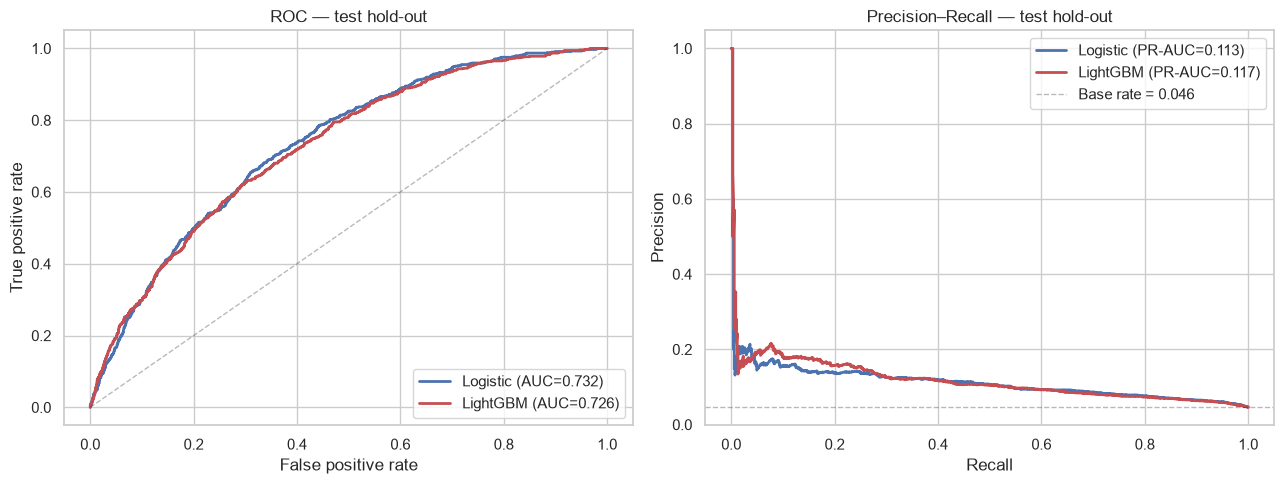

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ROC
fpr_log, tpr_log, _ = roc_curve(y_test, p_test_log)
fpr_lgb, tpr_lgb, _ = roc_curve(y_test, p_test_lgb)
axes[0].plot(fpr_log, tpr_log, label=f"Logistic (AUC={test_metrics_log['auc']:.3f})",
             linewidth=2, color="#4C72B0")
axes[0].plot(fpr_lgb, tpr_lgb, label=f"LightGBM (AUC={test_metrics_lgb['auc']:.3f})",
             linewidth=2, color="#C44E52")
axes[0].plot([0, 1], [0, 1], "k--", alpha=0.3, linewidth=1)
axes[0].set_xlabel("False positive rate")
axes[0].set_ylabel("True positive rate")
axes[0].set_title("ROC — test hold-out")
axes[0].legend(loc="lower right")

# Precision-Recall
prec_log, rec_log, _ = precision_recall_curve(y_test, p_test_log)
prec_lgb, rec_lgb, _ = precision_recall_curve(y_test, p_test_lgb)
axes[1].plot(rec_log, prec_log,
             label=f"Logistic (PR-AUC={test_metrics_log['pr_auc']:.3f})",
             linewidth=2, color="#4C72B0")
axes[1].plot(rec_lgb, prec_lgb,
             label=f"LightGBM (PR-AUC={test_metrics_lgb['pr_auc']:.3f})",
             linewidth=2, color="#C44E52")
axes[1].axhline(y_test.mean(), color="k", linestyle="--", alpha=0.3,
                linewidth=1, label=f"Base rate = {y_test.mean():.3f}")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("Precision–Recall — test hold-out")
axes[1].legend(loc="upper right")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "03_roc_pr_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

**Takeaway.** The operating family was locked from OOF evidence: LightGBM had to improve AUC by at least 0.005 to justify its added complexity. The observed OOF gain is below that threshold, so the logistic baseline is retained independently of the test result. Test metrics and paired bootstrap intervals quantify how uncertain the apparent differences are; they are evidence about generalisation, not a second selection round.

The next sensitivity check asks a different question: whether the locked logistic specification behaves similarly when trained on early cohorts and evaluated on later cohorts from the same vintage.


### 6.4 Chronological sensitivity analysis

The logistic specification and hyperparameters remain unchanged. It is refit on loans with `first_payment_date <= 201909` and evaluated on later first-payment cohorts. Because both groups belong to one vintage and their outcome windows overlap different calendar periods, this is a **sensitivity analysis**, not a true future-vintage validation.

In [17]:
X_time_train = loans.loc[time_train_mask].drop(columns=[TARGET])
y_time_train = loans.loc[time_train_mask, TARGET].astype(int)
X_time_test = loans.loc[time_test_mask].drop(columns=[TARGET])
y_time_test = loans.loc[time_test_mask, TARGET].astype(int)

features_time_train = build_derived(X_time_train)
features_time_test = build_derived(X_time_test)
X_time_train_banded = features_time_train[BANDED_FEATURES]
X_time_test_banded = features_time_test[BANDED_FEATURES]

temporal_log = make_logistic_pipeline(class_weight=None).fit(X_time_train_banded, y_time_train)
p_time_test = temporal_log.predict_proba(X_time_test_banded)[:, 1]
temporal_metrics = discrimination_metrics(y_time_test, p_time_test)

temporal_report = pd.DataFrame({
    "Random hold-out": {**test_metrics_log,
                        "observed_rate": y_test.mean(),
                        "mean_pd": p_test_log.mean()},
    "Chronological hold-out": {**temporal_metrics,
                               "observed_rate": y_time_test.mean(),
                               "mean_pd": p_time_test.mean()},
}).T
print(temporal_report.round(4))

                          auc  pr_auc     ks  brier  observed_rate  mean_pd
Random hold-out        0.7322  0.1125 0.3455 0.0424         0.0459   0.0455
Chronological hold-out 0.7149  0.1119 0.3115 0.0431         0.0465   0.0416


## 7. Feature importance and explainability

Two complementary views inspect the LightGBM challenger: gain importance summarises split usage, while SHAP attributes each row's raw model score across features. Neither is a causal explanation.

The purpose is diagnostic: compare the challenger's learned shapes with the broad descriptive patterns from notebook 02 and identify possible misspecification in the logistic baseline. FICO, LTV, DTI, and borrower structure are inspected explicitly. Apparent non-linearities or colour separation are treated as hypotheses, not proof of an interaction or validation of hand-crafted cutpoints. The selected logistic model's own reference-coded coefficients are reported separately.


### 7.1 LightGBM gain importance

In [18]:
importance_gain = pd.DataFrame({
    "feature": final_lgb.feature_name_,
    "gain":    final_lgb.booster_.feature_importance(importance_type="gain"),
    "splits":  final_lgb.booster_.feature_importance(importance_type="split"),
}).sort_values("gain", ascending=False).reset_index(drop=True)

importance_gain["gain_share"] = importance_gain["gain"] / importance_gain["gain"].sum()
print(importance_gain.assign(
    gain_share=lambda d: (d["gain_share"] * 100).map("{:.1f} %".format),
).to_string(index=False))

                  feature      gain  splits gain_share
         credit_score_raw 7261.8899     268     45.2 %
                  dti_raw 2547.9358     149     15.9 %
             original_upb 1764.2024     174     11.0 %
                  ltv_raw 1696.6377     163     10.6 %
        num_borrowers_bin  827.0037      64      5.1 %
                  channel  528.7666      48      3.3 %
         occupancy_status  431.3478      47      2.7 %
            region_census  326.2734      34      2.0 %
             loan_purpose  274.8217      30      1.7 %
first_time_homebuyer_flag  185.6111      15      1.2 %
             ftb_high_ltv   92.0759       9      0.6 %
            num_units_bin   90.5678      14      0.6 %
            property_type   44.7628       7      0.3 %


### 7.2 SHAP values on the test set

SHAP is used to inspect the LightGBM challenger, not to promote it to the operating model. Tree SHAP values are on the model's raw-score scale. The explainer's expected value is therefore reported as a raw reference score—not mislabeled as the portfolio base rate.


In [19]:
import shap

explainer = shap.Explainer(final_lgb)
shap_explanation = explainer(X_test_raw)
shap_values = shap_explanation.values
if shap_values.ndim == 3:
    shap_values = shap_values[:, :, 1]

base_values = np.asarray(shap_explanation.base_values)
base_raw_score = float(base_values.reshape(-1)[0])

print(f"SHAP values matrix: {shap_values.shape}")
print(f"Expected raw model score: {base_raw_score:.4f}")
print(f"Mean LightGBM PD on test: {p_test_lgb.mean():.4f}")
print(f"Observed test event rate: {y_test.mean():.4f}")


SHAP values matrix: (14984, 13)
Expected raw model score: -3.3247
Mean LightGBM PD on test: 0.0459
Observed test event rate: 0.0459


### 7.3 SHAP summary plot

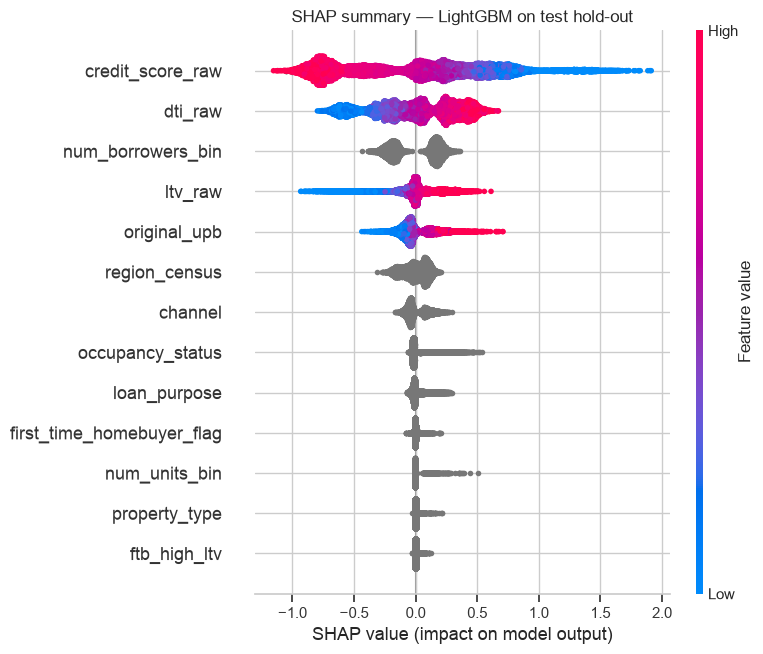

In [20]:
fig = plt.figure(figsize=(10, 6))
shap.summary_plot(
    shap_values, X_test_raw,
    plot_type="dot", show=False, max_display=15,
)
plt.title("SHAP summary — LightGBM on test hold-out")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "03_shap_summary.png", dpi=150, bbox_inches="tight")
plt.show()

### 7.4 SHAP dependence diagnostics

The colour feature is chosen to expose potential interactions: FICO is coloured by LTV, and LTV/DTI by FICO. These plots are exploratory diagnostics. Colour separation may suggest an interaction, but does not by itself establish one or validate a causal mechanism.


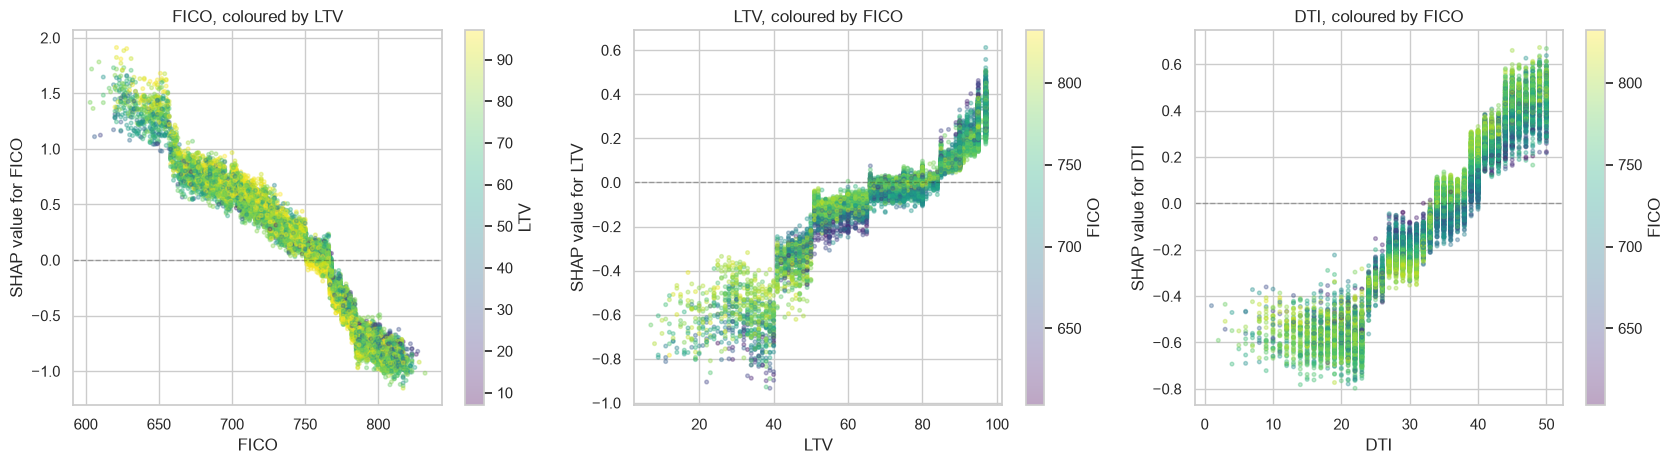

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.8))

specs = [
    ("credit_score_raw", "ltv_raw", "FICO", "LTV", "LTV"),
    ("ltv_raw", "credit_score_raw", "LTV", "FICO", "FICO"),
    ("dti_raw", "credit_score_raw", "DTI", "FICO", "FICO"),
]
for ax, (feature, color_feature, label, color_label, _) in zip(axes, specs):
    col_idx = X_test_raw.columns.get_loc(feature)
    points = ax.scatter(
        X_test_raw[feature], shap_values[:, col_idx],
        c=X_test_raw[color_feature], cmap="viridis", s=7, alpha=0.35,
    )
    ax.axhline(0, color="k", linestyle="--", alpha=0.3, linewidth=1)
    ax.set_xlabel(label)
    ax.set_ylabel(f"SHAP value for {label}")
    ax.set_title(f"{label}, coloured by {color_label}")
    fig.colorbar(points, ax=ax, label=color_label)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "03_shap_dependence_fico_ltv_dti.png",
            dpi=150, bbox_inches="tight")
plt.show()


### 7.5 Logistic coefficients relative to explicit references

With one category dropped per feature, every coefficient is a log-odds difference relative to the displayed reference level, conditional on the other encoded variables. Coefficient size is not a causal effect and rare levels remain less stable.


In [22]:
ohe = final_log.named_steps["preproc"].named_transformers_["cat"]
onehot_names = ohe.get_feature_names_out(BANDED_FEATURES)
coefs = final_log.named_steps["clf"].coef_[0]
reference_levels = {
    feature: categories[int(drop_idx)]
    for feature, categories, drop_idx in zip(BANDED_FEATURES, ohe.categories_, ohe.drop_idx_)
}

coef_table = (
    pd.DataFrame({"feature_level": onehot_names, "coef": coefs})
    .assign(abs_coef=lambda d: d["coef"].abs())
    .sort_values("abs_coef", ascending=False)
    .drop(columns="abs_coef")
    .reset_index(drop=True)
)
coef_table["feature"] = pd.NA
coef_table["level"] = pd.NA
for feat in BANDED_FEATURES:
    mask = coef_table["feature_level"].str.startswith(feat + "_")
    coef_table.loc[mask, "feature"] = feat
    coef_table.loc[mask, "level"] = coef_table.loc[mask, "feature_level"].str[len(feat)+1:]

print(f"Intercept: {final_log.named_steps['clf'].intercept_[0]:.4f}")
print("\nReference levels:")
print(pd.Series(reference_levels, name="reference").to_string())
print("\nTop 20 non-reference coefficients by magnitude:")
print(coef_table.head(20).to_string(index=False))

for feat in ["fico_band", "ltv_band", "dti_band"]:
    print(f"\n{feat} (reference={reference_levels[feat]}):")
    sub = coef_table[coef_table["feature"] == feat][["level", "coef"]]
    print(sub.sort_values("coef").to_string(index=False))


Intercept: -1.6981

Reference levels:
fico_band                       620-659
ltv_band                          60-70
dti_band                          30-36
region_census                   Midwest
num_units_bin                    1_unit
num_borrowers_bin            1_borrower
loan_purpose                          C
occupancy_status                      I
channel                               B
property_type                        CO
first_time_homebuyer_flag             N
ftb_high_ltv                         No

Top 20 non-reference coefficients by magnitude:
                     feature_level    coef           feature            level
                    fico_band_780+ -2.1233         fico_band             780+
                 fico_band_740-779 -1.4357         fico_band          740-779
                 fico_band_700-739 -0.9155         fico_band          700-739
                      ltv_band_>95  0.7958          ltv_band              >95
                    ltv_band_90-95  0.7026 

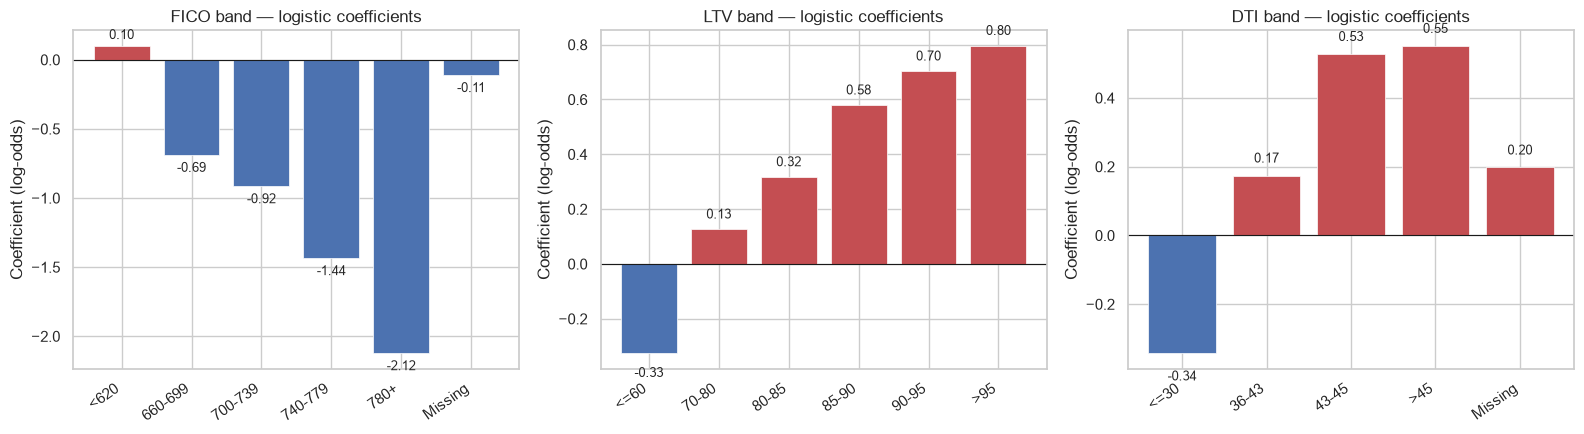

In [23]:
# Order bands as they appear naturally (not alphabetical)
FICO_ORDER_PLOT = ["<620", "620-659", "660-699", "700-739",
                   "740-779", "780+", "Missing"]
LTV_ORDER_PLOT  = ["<=60", "60-70", "70-80", "80-85",
                   "85-90", "90-95", ">95", "Missing"]
DTI_ORDER_PLOT  = ["<=30", "30-36", "36-43", "43-45", ">45", "Missing"]

def get_coefs_for_feature(feature_name, order):
    """Return a Series of coefs for a banded feature in the given order."""
    rows = coef_table[coef_table["feature"] == feature_name]
    coefs = rows.set_index("level")["coef"]
    return coefs.reindex(order).dropna()

fico_coefs = get_coefs_for_feature("fico_band", FICO_ORDER_PLOT)
ltv_coefs  = get_coefs_for_feature("ltv_band",  LTV_ORDER_PLOT)
dti_coefs  = get_coefs_for_feature("dti_band",  DTI_ORDER_PLOT)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

for ax, coefs, title in [
    (axes[0], fico_coefs, "FICO band — logistic coefficients"),
    (axes[1], ltv_coefs,  "LTV band — logistic coefficients"),
    (axes[2], dti_coefs,  "DTI band — logistic coefficients"),
]:
    colors = ["#C44E52" if c > 0 else "#4C72B0" for c in coefs.values]
    ax.bar(range(len(coefs)), coefs.values, color=colors,
           edgecolor="white", linewidth=0.5)
    ax.axhline(0, color="k", linewidth=0.8)
    ax.set_xticks(range(len(coefs)))
    ax.set_xticklabels(coefs.index, rotation=35, ha="right")
    ax.set_ylabel("Coefficient (log-odds)")
    ax.set_title(title)
    for i, v in enumerate(coefs.values):
        ax.text(i, v + (0.03 if v >= 0 else -0.05),
                f"{v:.2f}",
                ha="center",
                va="bottom" if v >= 0 else "top",
                fontsize=9)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "03_logistic_coefs_fico_ltv_dti.png",
            dpi=150, bbox_inches="tight")
plt.show()

**Takeaway.** The three views answer different questions. Gain and SHAP describe the flexible challenger; reference-coded logistic coefficients describe the selected model. Agreement on the broad importance of FICO, LTV, DTI, and borrower structure is reassuring, but exact curve shapes and colour patterns remain descriptive rather than causal.

The simplified `ftb_high_ltv` flag tests one prespecified business interaction without duplicating the entire FTB × LTV table. Interest rate no longer appears in either model because the score is explicitly defined before pricing. Rare bands—especially the very low-FICO tail—should still be interpreted cautiously and monitored or collapsed on a larger multi-vintage sample.


## 8. Calibration selected from OOF training evidence

Calibration is a model-selection step. Raw and isotonic predictions are therefore compared using nested out-of-fold predictions on the training set. Isotonic calibration is retained only if it improves OOF Brier score by at least 0.0001; the test set is used afterwards for diagnostics only.


### 8.1 Nested OOF calibration decision


In [24]:
def nested_calibrated_oof(X, y, n_splits=5, seed=SEED):
    outer = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)
    pred = np.zeros(len(y), dtype=float)
    for fold, (fit_idx, val_idx) in enumerate(outer.split(X, y), start=1):
        calibrator = CalibratedClassifierCV(
            estimator=make_logistic_pipeline(class_weight=None),
            method="isotonic", cv=3,
        )
        calibrator.fit(X.iloc[fit_idx], y.iloc[fit_idx])
        pred[val_idx] = calibrator.predict_proba(X.iloc[val_idx])[:, 1]
        print(f"calibration outer fold {fold}/{n_splits} complete")
    return pred

oof_log_calib = nested_calibrated_oof(X_train_banded, y_train.reset_index(drop=True))
CALIBRATION_MIN_BRIER_GAIN = 0.0001
oof_brier_raw = brier_score_loss(y_train, oof_log_none)
oof_brier_calib = brier_score_loss(y_train, oof_log_calib)
oof_brier_gain = oof_brier_raw - oof_brier_calib
USE_ISOTONIC = oof_brier_gain >= CALIBRATION_MIN_BRIER_GAIN

calibrated_log = CalibratedClassifierCV(
    estimator=make_logistic_pipeline(class_weight=None),
    method="isotonic", cv=5,
).fit(X_train_banded, y_train)
p_test_log_raw = p_test_log
p_test_log_calib = calibrated_log.predict_proba(X_test_banded)[:, 1]

print(f"OOF Brier, raw:        {oof_brier_raw:.6f}")
print(f"OOF Brier, isotonic:   {oof_brier_calib:.6f}")
print(f"OOF improvement:       {oof_brier_gain:+.6f}")
print(f"Required improvement:  {CALIBRATION_MIN_BRIER_GAIN:.6f}")
print(f"Use isotonic:          {USE_ISOTONIC}")
print(f"\nTest Brier, raw:      {brier_score_loss(y_test, p_test_log_raw):.6f}")
print(f"Test Brier, isotonic: {brier_score_loss(y_test, p_test_log_calib):.6f}")


calibration outer fold 1/5 complete
calibration outer fold 2/5 complete
calibration outer fold 3/5 complete
calibration outer fold 4/5 complete
calibration outer fold 5/5 complete
OOF Brier, raw:        0.042517
OOF Brier, isotonic:   0.042574
OOF improvement:       -0.000057
Required improvement:  0.000100
Use isotonic:          False

Test Brier, raw:      0.042375
Test Brier, isotonic: 0.042414


### 8.2 Test reliability diagram — diagnostic only


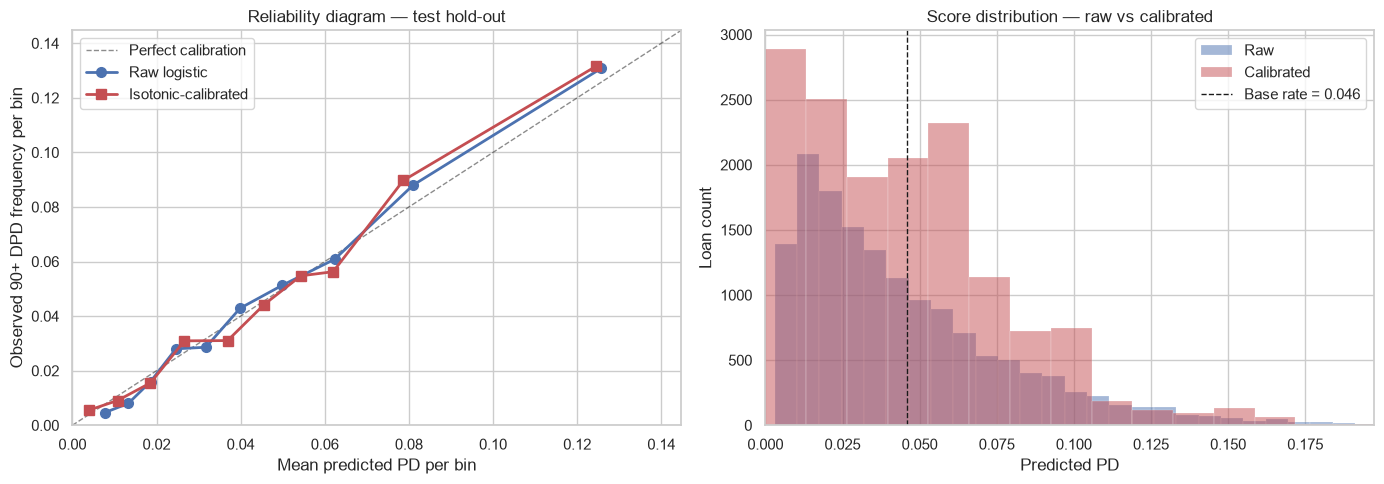

In [25]:
N_BINS = 10

frac_raw,   mean_raw   = calibration_curve(y_test, p_test_log_raw,   n_bins=N_BINS,
                                            strategy="quantile")
frac_calib, mean_calib = calibration_curve(y_test, p_test_log_calib, n_bins=N_BINS,
                                            strategy="quantile")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: raw vs calibrated reliability curves
axes[0].plot([0, 1], [0, 1], "k--", linewidth=1, alpha=0.5,
             label="Perfect calibration")
axes[0].plot(mean_raw, frac_raw, "o-", color="#4C72B0", linewidth=2,
             markersize=7, label="Raw logistic")
axes[0].plot(mean_calib, frac_calib, "s-", color="#C44E52", linewidth=2,
             markersize=7, label="Isotonic-calibrated")
# Zoom on the operational range
max_pt = max(frac_raw.max(), frac_calib.max(), mean_raw.max(), mean_calib.max())
axes[0].set_xlim(0, max_pt * 1.1)
axes[0].set_ylim(0, max_pt * 1.1)
axes[0].set_xlabel("Mean predicted PD per bin")
axes[0].set_ylabel("Observed 90+ DPD frequency per bin")
axes[0].set_title("Reliability diagram — test hold-out")
axes[0].legend(loc="upper left")

# Right: score distribution for context
axes[1].hist(p_test_log_raw,   bins=50, alpha=0.5, color="#4C72B0",
             label="Raw",  edgecolor="white", linewidth=0.3)
axes[1].hist(p_test_log_calib, bins=50, alpha=0.5, color="#C44E52",
             label="Calibrated", edgecolor="white", linewidth=0.3)
axes[1].axvline(y_test.mean(), color="k", linestyle="--", linewidth=1,
                label=f"Base rate = {y_test.mean():.3f}")
axes[1].set_xlabel("Predicted PD")
axes[1].set_ylabel("Loan count")
axes[1].set_title("Score distribution — raw vs calibrated")
axes[1].legend()
axes[1].set_xlim(0, max_pt * 1.5)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "03_reliability_diagram.png",
            dpi=150, bbox_inches="tight")
plt.show()

### 8.3 Calibration diagnostics

The exact Brier score is reported together with Brier skill against the constant training-base-rate forecast. ECE and MCE are **quantile-bin summaries**, not exact decompositions; they help localise calibration error without pretending that a grouped approximation exactly reconstructs the Brier score.


In [26]:
def calibration_diagnostics(y_true, y_pred, reference_rate, n_bins=10):
    frame = pd.DataFrame({"y": np.asarray(y_true), "p": np.asarray(y_pred)})
    frame["bin"] = pd.qcut(frame["p"], q=n_bins, duplicates="drop")
    grouped = frame.groupby("bin", observed=True).agg(
        n=("y", "size"), mean_pd=("p", "mean"), observed_rate=("y", "mean")
    )
    abs_gap = (grouped["mean_pd"] - grouped["observed_rate"]).abs()
    brier = brier_score_loss(frame["y"], frame["p"])
    baseline_brier = np.mean((frame["y"] - reference_rate) ** 2)
    summary = {
        "brier": brier,
        "brier_skill": 1 - brier / baseline_brier,
        "ece_quantile": np.average(abs_gap, weights=grouped["n"]),
        "mce_quantile": abs_gap.max(),
    }
    return summary, grouped

diag_raw, calibration_bins_raw = calibration_diagnostics(
    y_test, p_test_log_raw, reference_rate=y_train.mean()
)
diag_calib, calibration_bins_calib = calibration_diagnostics(
    y_test, p_test_log_calib, reference_rate=y_train.mean()
)
calibration_table = pd.DataFrame({
    "Raw logistic": diag_raw,
    "Isotonic": diag_calib,
}).T
print(calibration_table.round(6))


              brier  brier_skill  ece_quantile  mce_quantile
Raw logistic 0.0424       0.0327        0.0035        0.0070
Isotonic     0.0424       0.0318        0.0042        0.0110


### 8.4 Freeze the operating score

The choice below follows only the nested OOF rule. Both candidate test predictions were computed for transparent diagnostics, but the test result cannot override the OOF decision.


In [27]:
operating_model = calibrated_log if USE_ISOTONIC else final_log
operating_pd_oof = oof_log_calib if USE_ISOTONIC else oof_log_none
operating_pd_test = p_test_log_calib if USE_ISOTONIC else p_test_log_raw
operating_label = "isotonic-calibrated logistic" if USE_ISOTONIC else "raw logistic"

print(f"Operating model: {operating_label}")
print(f"OOF PDs:  mean={operating_pd_oof.mean():.4f}, min={operating_pd_oof.min():.4f}, max={operating_pd_oof.max():.4f}")
print(f"Test PDs: mean={operating_pd_test.mean():.4f}, min={operating_pd_test.min():.4f}, max={operating_pd_test.max():.4f}")


Operating model: raw logistic
OOF PDs:  mean=0.0459, min=0.0027, max=0.3833
Test PDs: mean=0.0455, min=0.0030, max=0.3647


**Takeaway.** Calibration is retained only when its nested OOF Brier improvement clears the prespecified threshold. This prevents a visually attractive test reliability curve from becoming an implicit model-selection device. The reliability diagram and quantile-bin ECE/MCE remain useful diagnostics, but they do not prove stability under future distribution shift.

All reported PDs estimate the probability of the observed 90+ DPD label. Without assistance-status data or another outcome definition, no adjustment for an unobserved “economic default” is made.


## 9. Scenario portfolio-selection layer

This section does **not** recreate a historical approval process: every row is an originated Freddie Mac loan, and rejected applicants are absent. It illustrates how a frozen risk score could rank or screen loans **within this observed acquisition population** under explicit margin and LGD assumptions. Dollar results are scenario values, not realized accounting P&L.


### 9.1 Scenario value assumptions and fixed economic cutoff

For illustration, a performing loan earns 1.5% annual margin for two years and a 90+ DPD event incurs 25% of UPB. These are transparent assumptions, not estimates from the dataset. Their algebraic break-even PD is fixed before test evaluation.


In [28]:
LGD = 0.25
MARGIN_PCT = 0.015
OBS_YEARS = 2
PD_BREAKEVEN = (MARGIN_PCT * OBS_YEARS) / (MARGIN_PCT * OBS_YEARS + LGD)

def scenario_value(y_true, upb):
    y_arr = np.asarray(y_true)
    upb_arr = np.asarray(upb, dtype=float)
    return np.where(
        y_arr == 0,
        MARGIN_PCT * OBS_YEARS * upb_arr,
        -LGD * upb_arr,
    )

upb_train = X_train["original_upb"].to_numpy(dtype=float)
upb_test = X_test["original_upb"].to_numpy(dtype=float)
fico_train = X_train["credit_score"].to_numpy(dtype=float)
fico_test = X_test["credit_score"].to_numpy(dtype=float)
scenario_pnl_train = scenario_value(y_train, upb_train)
scenario_pnl_test = scenario_value(y_test, upb_test)

print(f"Fixed break-even PD: {PD_BREAKEVEN:.4f} ({PD_BREAKEVEN*100:.2f} %)")
print(f"Test portfolio:       {len(y_test):,} loans, ${upb_test.sum()/1e9:.2f} B UPB")
print(f"Approve-all scenario value: ${scenario_pnl_test.sum()/1e6:+.2f} M")


Fixed break-even PD: 0.1071 (10.71 %)
Test portfolio:       14,984 loans, $3.84 B UPB
Approve-all scenario value: $+61.32 M


### 9.2 Training diagnostics and frozen test evaluation

The OOF threshold sweep shows sensitivity on training data only. The operating cutoff is the algebraic break-even PD above—not the maximum of the test curve. The fixed policy is then evaluated once on test, with a paired bootstrap interval for its value lift versus acquiring every loan.


In [29]:
cutoffs = np.linspace(0.005, 0.30, 300)
sweep_rows = []
for cutoff in cutoffs:
    selected = operating_pd_oof < cutoff
    if selected.sum() == 0:
        continue
    sweep_rows.append({
        "cutoff": cutoff,
        "selection_rate": selected.mean(),
        "n_selected": int(selected.sum()),
        "event_rate_selected": y_train.to_numpy()[selected].mean(),
        "scenario_value_M": scenario_pnl_train[selected].sum() / 1e6,
    })
sweep = pd.DataFrame(sweep_rows)

selected_test = operating_pd_test < PD_BREAKEVEN
model_value_test = scenario_pnl_test[selected_test].sum()
approve_all_value_test = scenario_pnl_test.sum()
model_lift_test = model_value_test - approve_all_value_test

def bootstrap_policy_lift(values, selected_a, selected_b=None, n_boot=1000, seed=SEED):
    """Paired CI for value(policy A) - value(policy B); B defaults to select all."""
    values = np.asarray(values)
    selected_a = np.asarray(selected_a, dtype=bool)
    selected_b = np.ones(len(values), dtype=bool) if selected_b is None else np.asarray(selected_b, dtype=bool)
    per_loan_delta = values * (selected_a.astype(int) - selected_b.astype(int))
    rng = np.random.default_rng(seed)
    draws = np.empty(n_boot)
    for i in range(n_boot):
        idx = rng.integers(0, len(values), len(values))
        draws[i] = per_loan_delta[idx].sum()
    return np.quantile(draws, [0.025, 0.975])

lift_ci = bootstrap_policy_lift(scenario_pnl_test, selected_test)
print(f"Frozen PD cutoff:          {PD_BREAKEVEN*100:.2f} %")
print(f"Test selection rate:       {selected_test.mean()*100:.2f} %")
print(f"Test event rate selected:  {y_test.to_numpy()[selected_test].mean()*100:.3f} %")
print(f"Test scenario value:       ${model_value_test/1e6:+.2f} M")
print(f"Lift vs select all:        ${model_lift_test/1e6:+.2f} M")
print(f"95% paired bootstrap CI:   [${lift_ci[0]/1e6:+.2f} M, ${lift_ci[1]/1e6:+.2f} M]")


Frozen PD cutoff:          10.71 %
Test selection rate:       93.46 %
Test event rate selected:  3.942 %
Test scenario value:       $+64.05 M
Lift vs select all:        $+2.73 M
95% paired bootstrap CI:   [$+1.05 M, $+4.35 M]


### 9.3 FICO-cutoff benchmark selected on training data

Candidate FICO cutoffs are compared on the training sample only. The best training cutoff is frozen, then evaluated on test. This benchmark remains descriptive of the observed Freddie population; it is not a reconstruction of industry underwriting rules.


In [30]:
fico_cutoffs = [600, 620, 640, 660, 680, 700, 720, 740]
fico_train_rows = []
for cutoff in fico_cutoffs:
    selected = fico_train >= cutoff
    fico_train_rows.append({
        "fico_cutoff": cutoff,
        "selection_rate": selected.mean(),
        "scenario_value_M": scenario_pnl_train[selected].sum() / 1e6,
    })
fico_train_table = pd.DataFrame(fico_train_rows)
best_fico_cutoff = int(fico_train_table.loc[
    fico_train_table["scenario_value_M"].idxmax(), "fico_cutoff"
])

fico_test_rows = []
for cutoff in fico_cutoffs:
    selected = fico_test >= cutoff
    fico_test_rows.append({
        "fico_cutoff": cutoff,
        "selection_rate": selected.mean(),
        "n_selected": int(selected.sum()),
        "event_rate_selected": y_test.to_numpy()[selected].mean(),
        "scenario_value_M": scenario_pnl_test[selected].sum() / 1e6,
    })
fico_table = pd.DataFrame(fico_test_rows)
selected_fico_test = fico_test >= best_fico_cutoff
best_fico_test_value = scenario_pnl_test[selected_fico_test].sum()

print("Training policy table:")
print(fico_train_table.round(4).to_string(index=False))
print(f"\nFrozen FICO cutoff selected on train: FICO >= {best_fico_cutoff}")
print("\nTest diagnostics:")
print(fico_table.round(4).to_string(index=False))
print(f"Frozen FICO test scenario value: ${best_fico_test_value/1e6:+.2f} M")


Training policy table:
 fico_cutoff  selection_rate  scenario_value_M
         600          0.9996          145.4158
         620          0.9991          145.5070
         640          0.9867          145.5713
         660          0.9629          147.2740
         680          0.9232          145.5701
         700          0.8488          141.3781
         720          0.7467          134.8106
         740          0.6269          122.8046

Frozen FICO cutoff selected on train: FICO >= 660

Test diagnostics:
 fico_cutoff  selection_rate  n_selected  event_rate_selected  scenario_value_M
         600          0.9995       14977               0.0459           61.3056
         620          0.9986       14963               0.0459           61.2503
         640          0.9857       14770               0.0450           61.3932
         660          0.9617       14410               0.0436           61.1434
         680          0.9224       13821               0.0417           60.5944
    

### 9.4 Trade-off chart

The left panel is an OOF training sensitivity curve. The right panel reports test outcomes for policies whose rules were fixed from training evidence or economic assumptions. The panels are intentionally labelled to prevent the training sweep from being read as a test-optimised result.


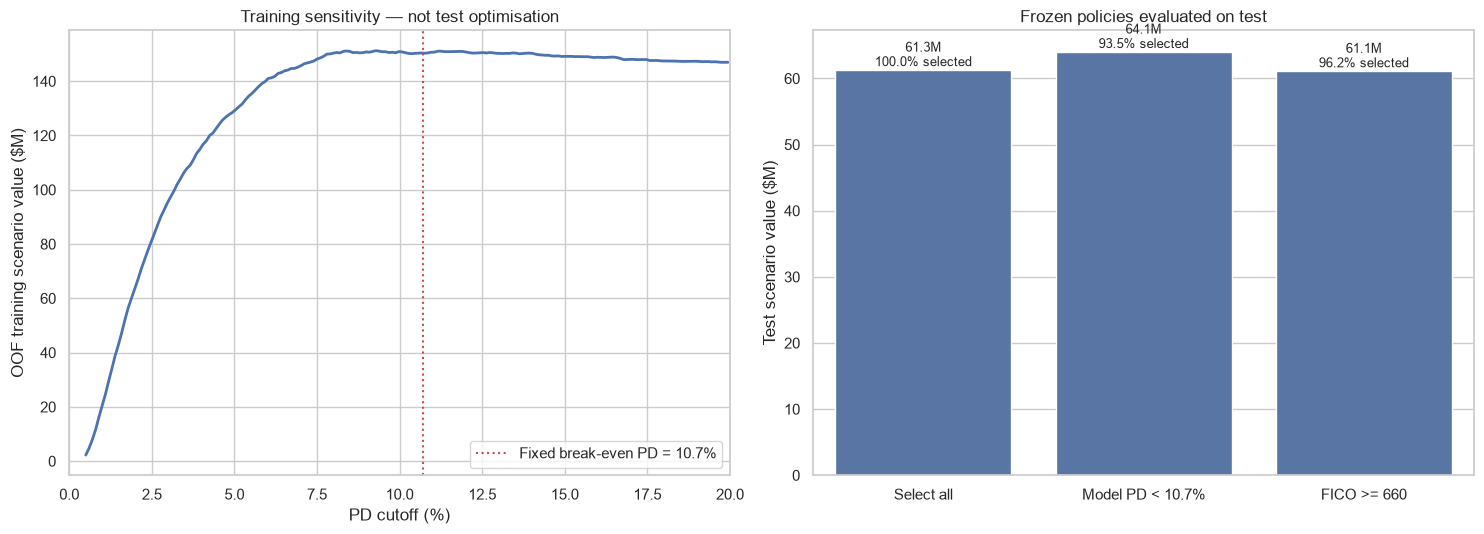

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

mask_cut = sweep["cutoff"] <= 0.20
axes[0].plot(
    sweep.loc[mask_cut, "cutoff"] * 100,
    sweep.loc[mask_cut, "scenario_value_M"],
    color="#4C72B0", linewidth=2,
)
axes[0].axvline(PD_BREAKEVEN * 100, color="#C44E52", linestyle=":",
                linewidth=1.5, label=f"Fixed break-even PD = {PD_BREAKEVEN*100:.1f}%")
axes[0].set_xlabel("PD cutoff (%)")
axes[0].set_ylabel("OOF training scenario value ($M)")
axes[0].set_title("Training sensitivity — not test optimisation")
axes[0].set_xlim(0, 20)
axes[0].legend()

test_policy_table = pd.DataFrame({
    "policy": ["Select all", f"Model PD < {PD_BREAKEVEN*100:.1f}%", f"FICO >= {best_fico_cutoff}"],
    "selection_rate": [1.0, selected_test.mean(), selected_fico_test.mean()],
    "scenario_value_M": [approve_all_value_test/1e6, model_value_test/1e6, best_fico_test_value/1e6],
})
sns.barplot(data=test_policy_table, x="policy", y="scenario_value_M", ax=axes[1],
            color="#4C72B0")
for i, row in test_policy_table.iterrows():
    axes[1].text(i, row["scenario_value_M"],
                 f"{row['scenario_value_M']:.1f}M\n{row['selection_rate']*100:.1f}% selected",
                 ha="center", va="bottom", fontsize=9)
axes[1].set_xlabel("")
axes[1].set_ylabel("Test scenario value ($M)")
axes[1].set_title("Frozen policies evaluated on test")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "03_cutoff_tradeoff.png", dpi=150, bbox_inches="tight")
plt.show()


### 9.5 Matched-selection comparison without test tuning

For each prespecified FICO cutoff, the corresponding selection rate is measured on training data. An OOF model threshold is chosen to match that training rate, then both fixed thresholds are applied to test. This avoids choosing a model cutoff from realised test outcomes. Paired intervals show whether scenario-value differences are distinguishable from sampling noise.


In [32]:
matched_rows = []
for cutoff in fico_cutoffs:
    fico_selected_train = fico_train >= cutoff
    target_rate = fico_selected_train.mean()
    model_threshold = float(np.quantile(operating_pd_oof, target_rate))

    fico_selected_test = fico_test >= cutoff
    model_selected_test = operating_pd_test < model_threshold
    fico_value = scenario_pnl_test[fico_selected_test].sum()
    model_value = scenario_pnl_test[model_selected_test].sum()
    ci = bootstrap_policy_lift(
        scenario_pnl_test, model_selected_test, fico_selected_test,
        n_boot=500, seed=SEED + cutoff,
    )
    matched_rows.append({
        "fico_cutoff": cutoff,
        "train_target_rate_pct": target_rate * 100,
        "model_pd_cutoff_pct": model_threshold * 100,
        "fico_test_rate_pct": fico_selected_test.mean() * 100,
        "model_test_rate_pct": model_selected_test.mean() * 100,
        "fico_value_M": fico_value / 1e6,
        "model_value_M": model_value / 1e6,
        "model_lift_M": (model_value - fico_value) / 1e6,
        "ci_low_M": ci[0] / 1e6,
        "ci_high_M": ci[1] / 1e6,
    })

matched = pd.DataFrame(matched_rows)
print(matched.round(3).to_string(index=False))
print("\nPositive lift favours the model; intervals crossing zero are inconclusive.")


 fico_cutoff  train_target_rate_pct  model_pd_cutoff_pct  fico_test_rate_pct  model_test_rate_pct  fico_value_M  model_value_M  model_lift_M  ci_low_M  ci_high_M
         600                99.9630              28.4100             99.9530              99.9800       61.3060        61.3650        0.0590   -0.0320     0.1530
         620                99.9060              24.6490             99.8600              99.9130       61.2500        61.3750        0.1240   -0.0160     0.3060
         640                98.6670              16.1630             98.5720              98.7590       61.3930        62.1530        0.7600   -0.1150     1.6820
         660                96.2930              12.8740             96.1690              96.6630       61.1430        63.0450        1.9010    0.6940     3.0170
         680                92.3230              10.4720             92.2380              92.9320       60.5940        64.0960        3.5020    1.8030     5.2800
         700                

## 10. Conclusion and case-study hand-off

### 10.1 Final result

The operating model is the **raw reference-coded logistic regression**. LightGBM improves OOF AUC by only 0.0023, below the prespecified 0.005 materiality threshold. On the untouched random test set, logistic performance is AUC **0.7322**, PR-AUC **0.1125**, KS **0.3455**, and Brier **0.0424**. The paired AUC difference for LightGBM minus logistic is −0.0057 with a 95% bootstrap interval of **[−0.0154, 0.0026]**: the test does not establish a material difference.

Isotonic calibration is not retained: nested OOF Brier worsens from 0.042517 to 0.042574. The chronological sensitivity check is weaker than the random hold-out (AUC **0.7149**) and underpredicts the later-cohort event rate (mean PD 4.16% vs observed 4.65%), reinforcing the need for genuine multi-vintage validation.

Under the illustrative 25% LGD and 3% two-year margin assumptions, the algebraic break-even cutoff is **10.71%**. Applied without test tuning, it selects 93.46% of test loans and produces a **+$2.73M scenario-value lift** versus selecting all loans, with a paired 95% bootstrap interval of **[+$1.05M, +$4.35M]**. These are scenario results inside an already-originated Freddie population—not realised P&L or an applicant approval estimate.

### 10.2 Corrections embodied in the workflow

- Model family, calibration, FICO benchmark, and score thresholds are chosen using training/OOF evidence only.
- Logistic categories have explicit reference levels; the former redundant full FTB × LTV cross is replaced by `ftb_high_ltv`.
- `original_interest_rate` is excluded at the declared pre-pricing scoring moment; all other exclusions are documented.
- Test model differences and policy-value lifts carry paired bootstrap intervals.
- The chronological split now reports actual predictive performance instead of prevalence alone.
- SHAP's expected raw score is no longer described as a base rate, and dependence plots are labelled exploratory.
- The approximate Brier decomposition is replaced by exact Brier/Brier skill plus clearly labelled quantile-bin ECE and MCE.
- “Realized P&L”, “optimal test cutoff”, “approval policy”, and “Pareto dominance” claims are removed.

### 10.3 Limits that must travel with the result

- The sample contains originated Freddie Mac loans only; rejected applicants and causal selection effects are unobserved.
- `default_24m` is a recorded 90+ DPD event, not charge-off or realised loss. LGD and margin are assumptions.
- Assistance status is unavailable, so any COVID-era label distortion cannot be signed or quantified here.
- Both validation views use one vintage. A later origination vintage is required for true out-of-time testing.
- Bootstrap intervals condition on this sample and scenario; they exclude uncertainty in LGD, margin, and the macro environment.

### 10.4 Recommended charts for notebook 04

1. `figures/03_reliability_diagram.png` — test diagnostic, with the calibration decision made on nested OOF evidence.
2. `figures/03_logistic_coefs_fico_ltv_dti.png` — auditable non-reference effects.
3. `figures/03_cutoff_tradeoff.png` — OOF threshold sensitivity beside frozen-policy test scenario values.
